In [6]:
!pip install torchcodec

In [7]:
!pip install torch torchaudio

데이터 모양(Shape): torch.Size([1, 225280])
샘플 레이트(Sample Rate): 16000 Hz


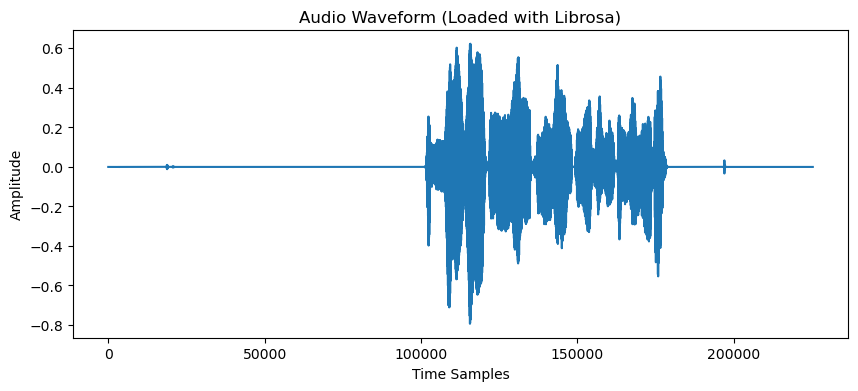

In [8]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

import librosa
import torch
import matplotlib.pyplot as plt

# 1. librosa를 이용해 음성 파일 불러오기
# sr=None을 적어주어야 원래 음성 파일이 가진 고유의 샘플 레이트로 정확히 읽어옵니다.
y, sr = librosa.load("sample.wav", sr=None)

# 2. 파이토치 모델(ResNet)에 넣을 수 있도록 PyTorch Tensor 데이터 형태로 변환합니다.
# librosa는 데이터를 기본적으로 numpy 배열로 가져오기 때문에 변환이 필요합니다.
waveform = torch.FloatTensor(y).unsqueeze(0) # [1, 샘플 수] 모양으로 차원 맞추기
sample_rate = sr

print("데이터 모양(Shape):", waveform.shape) 
print("샘플 레이트(Sample Rate):", sample_rate, "Hz")

# 3. 파형(Waveform) 그래프 그리기
plt.figure(figsize=(10, 4))
plt.plot(waveform[0].numpy()) 
plt.title("Audio Waveform (Loaded with Librosa)")
plt.xlabel("Time Samples")
plt.ylabel("Amplitude")
plt.show()

스펙트로그램 모양(Shape): torch.Size([1, 201, 1127])


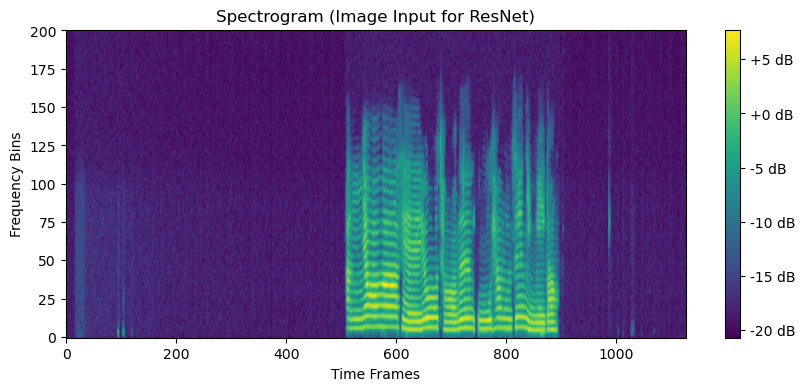

In [9]:
import torch
import torchaudio

# 1. 스펙트로그램 변환기 정의 (파이토치 내장 기능 사용)
# n_fft: 음성을 얼만큼의 길이로 쪼개서 주파수 분석을 할 것인가
spectrogram_transform = torchaudio.transforms.Spectrogram(n_fft=400)

# 2. 변환 적용
spectrogram = spectrogram_transform(waveform)

print("스펙트로그램 모양(Shape):", spectrogram.shape) # [채널, 주파수 축, 시간 축] -> 완벽한 2D 이미지 형태!

# 3. 소리는 로그(Log) 스케일로 봐야 시각적으로 잘 보입니다.
log_spectrogram = torch.log(spectrogram + 1e-9)

# 4. 이미지로 시각화
plt.figure(figsize=(10, 4))
plt.imshow(log_spectrogram[0].numpy(), origin="lower", aspect="auto", cmap="viridis")
plt.title("Spectrogram (Image Input for ResNet)")
plt.xlabel("Time Frames")
plt.ylabel("Frequency Bins")
plt.colorbar(format="%+2.0f dB")
plt.show()